# Assignment 6: Building Your First Neural Network

**Student Name:** Reagan O'Donnell

**Date:** 3/15/26

---

## Assignment Overview

You'll build feedforward neural networks to classify human activities from sensor data. You'll experiment with different architectures, compare performance against Unit 7's PCA+Random Forest approach, and learn when neural networks justify their added complexity.

---

## Step 1: Import Libraries and Load Data

In [ ]:
pip install pandas numpy matplotlib seaborn scikit-learn tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.7/200.7 MB 24.6 MB/s eta 0:00:00m eta 0:00:010:01:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 26.8 MB/s eta 0:00:000:00:0136m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 27.7 MB/s eta 0:00:0031m28.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.9/676.9 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 23.7 MB/s eta 0:00:00m eta 0:00:01

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")

✓ Libraries imported successfully
TensorFlow version: 2.18.0


In [2]:
# Load the Human Activity Recognition dataset
# TODO: Load train.csv and test.csv from the data folder
train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")

# TODO: Separate features from labels
# The 'Activity' column contains the labels (1-6)
X_train = train_df.drop('Activity', axis=1).values
y_train = train_df['Activity'].values
X_test = test_df.drop('Activity', axis=1).values
y_test = test_df['Activity'].values

# Encode string labels to integers (0-5)
# Neural networks need numerical labels
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

print("\n" + "="*80)
print("CHECKPOINT: Verify dataset loaded correctly")
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Number of features: {X_train.shape[1]}")
print(f"Number of activities: {len(np.unique(y_train))}")
print(f"Activity labels range: {y_train.min()} to {y_train.max()}")
print(f"Activity classes: {label_encoder.classes_}")
print("="*80)


CHECKPOINT: Verify dataset loaded correctly
Training set shape: (7352, 562)
Test set shape: (2947, 562)
Number of features: 562
Number of activities: 6
Activity labels range: 0 to 5
Activity classes: ['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']


### Standardize Features

Neural networks learn best when features are normalized to similar scales

In [3]:
# TODO: Use StandardScaler to normalize features
# Fit on training data, transform both train and test

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n" + "="*80)
print("CHECKPOINT: Features Standardized")
print(f"Mean of scaled features: {X_train_scaled.mean():.6f}")
print(f"Std of scaled features: {X_train_scaled.std():.6f}")
print("="*80)


CHECKPOINT: Features Standardized
Mean of scaled features: 0.000000
Std of scaled features: 1.000000


---
## Step 2: Build and Train Baseline Neural Network

### Create Baseline Architecture (1 Hidden Layer)

In [4]:
# TODO: Build a Sequential model with:
# - Input layer: Dense(64, activation='relu', input_shape=(562,))
# - Output layer: Dense(6, activation='softmax')

baseline_model = keras.Sequential([
    keras.Input(shape=(562,)), 
    layers.Dense(64, activation='relu'),
    layers.Dense(6, activation='softmax')
])

baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# Display model architecture
if baseline_model is not None:
    baseline_model.summary()
else:
    print("Model not created yet")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        36,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,422 (142.27 KB)

 Trainable params: 36,422 (142.27 KB)

 Non-trainable params: 0 (0.00 B)

### Train Baseline Model

In [5]:
# TODO: Train the model for 20 epochs with validation_split=0.2
# Save the training history and training time

print("Training baseline model (1 hidden layer, 64 nodes)...")
start_time = time.time()

# Your training code here
baseline_history = baseline_model.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    validation_split=0.2,
    verbose=1
)

baseline_time = time.time() - start_time

# TODO: Evaluate on test set
baseline_test_loss, baseline_test_accuracy = baseline_model.evaluate(X_test_scaled, y_test, verbose=0)  

print("\n" + "="*80)
print("BASELINE MODEL RESULTS")
print("="*80)
print(f"Architecture: 1 hidden layer, 64 nodes")
print(f"Test accuracy: {baseline_test_accuracy if baseline_test_accuracy else 'Not calculated'}")
print(f"Training time: {baseline_time:.2f} seconds")
print("="*80)

Training baseline model (1 hidden layer, 64 nodes)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7795 - loss: 0.5727 - val_accuracy: 0.9252 - val_loss: 0.1856
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9690 - loss: 0.1003 - val_accuracy: 0.9313 - val_loss: 0.1612
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9798 - loss: 0.0652 - val_accuracy: 0.9341 - val_loss: 0.1628
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9844 - loss: 0.0505 - val_accuracy: 0.9341 - val_loss: 0.1776
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9866 - loss: 0.0408 - val_accuracy: 0.9347 - val_loss: 0.1954
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9869 - loss: 0.0356 - val_accuracy: 0.9334 - val_loss: 0.2045
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9892 - loss: 0.0315 - val_accuracy: 0.9361 - val_loss: 0.2084
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/ste

---
## Step 3: Experiment with Network Depth (Number of Layers)

### Shallow Network (1 Layer) - Already Done Above

Baseline model = 1 hidden layer with 64 nodes

### Medium Network (2 Layers)

In [6]:
# TODO: Build model with 2 hidden layers:
# - Dense(128, activation='relu', input_shape=(562,))
# - Dense(64, activation='relu')
# - Dense(6, activation='softmax')

medium_model = keras.Sequential([
    keras.Input(shape=(562,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(6, activation='softmax')
])  

medium_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# TODO: Train for 20 epochs with validation_split=0.2
print("Training medium network (2 hidden layers)...")
medium_history = medium_model.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    validation_split=0.2,
    verbose=0
)

# TODO: Evaluate on test set
medium_test_loss, medium_test_accuracy = medium_model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"\nMedium network test accuracy: {medium_test_accuracy if medium_test_accuracy else 'Not calculated'}")

Training medium network (2 hidden layers)...

Medium network test accuracy: 0.929419755935669


### Deep Network (3 Layers)

In [7]:
# TODO: Build model with 3 hidden layers:
# - Dense(128, activation='relu', input_shape=(562,))
# - Dense(64, activation='relu')
# - Dense(32, activation='relu')
# - Dense(6, activation='softmax')

deep_model = keras.Sequential([
    keras.Input(shape=(562,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(6, activation='softmax')
])

deep_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# TODO: Train for 20 epochs with validation_split=0.2
print("Training deep network (3 hidden layers)...")
deep_history = deep_model.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    validation_split=0.2,
    verbose=0
)

# TODO: Evaluate on test set
deep_test_loss, deep_test_accuracy = deep_model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"\nDeep network test accuracy: {deep_test_accuracy if deep_test_accuracy else 'Not calculated'}")

Training deep network (3 hidden layers)...

Deep network test accuracy: 0.9402782320976257


### Compare Depth Experiments

In [9]:
# TODO: Create comparison of depth experiments
depth_results = pd.DataFrame({
    'Architecture': ['1 Layer (64)', '2 Layers (128, 64)', '3 Layers (128, 64, 32)'],
    'Test Accuracy': [baseline_test_accuracy, medium_test_accuracy, deep_test_accuracy]
})

print("\n" + "="*80)
print("DEPTH EXPERIMENT RESULTS")
print("="*80)
print(depth_results.to_string(index=False))
print("="*80)


DEPTH EXPERIMENT RESULTS
          Architecture  Test Accuracy
          1 Layer (64)       0.921955
    2 Layers (128, 64)       0.929420
3 Layers (128, 64, 32)       0.940278


### Reflection on Network Depth
In the Markdown cell below, write 2-3 sentences that answer the following questions: 
- How does adding more layers affect performance? 
- At what point do you see diminishing returns?

Adding more layers, compared to the baseline model, generally improved performace (accuracy). As you can see from the chart, the increase from base to medium layer was about .8% increase compared to the increase from medium to deep being 1.1%. The diminishing returns come in from deep layer with most net gain percentage of accuracy. The sweet spot of this turns out to be in the deep layer which would make sense witht the more layers it ran the model through.

---
## Step 4: Experiment with Network Width (Nodes Per Layer)

### Narrow Network (2 Layers, 32 Nodes Each)

In [10]:
# TODO: Build model with 2 layers of 32 nodes each
# - Dense(32, activation='relu', input_shape=(562,))
# - Dense(32, activation='relu')
# - Dense(6, activation='softmax')

narrow_model = keras.Sequential([
    keras.Input(shape=(562,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(6, activation='softmax')
])

narrow_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# TODO: Train for 20 epochs
print("Training narrow network (2 layers, 32 nodes each)...")
narrow_history = narrow_model.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    validation_split=0.2,
    verbose=0
)

# TODO: Evaluate
narrow_test_loss, narrow_test_accuracy = narrow_model.evaluate(X_test_scaled, y_test)

print(f"\nNarrow network test accuracy: {narrow_test_accuracy if narrow_test_accuracy else 'Not calculated'}")

Training narrow network (2 layers, 32 nodes each)...
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 734us/step - accuracy: 0.9141 - loss: 0.5147

Narrow network test accuracy: 0.9209365248680115


### Medium Width Network (2 Layers, 64 Nodes Each)

In [11]:
# TODO: Build model with 2 layers of 64 nodes each
medium_width_model = keras.Sequential([
    keras.Input(shape=(562,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(6, activation='softmax')
])

medium_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# TODO: Train for 20 epochs and 64 nodes
print("Training medium-width network (2 layers, 64 nodes each)...")
medium_width_history = medium_model.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    validation_split=0.2,
    verbose=0
)

# TODO: Evaluate
medium_width_test_loss, medium_width_test_accuracy = medium_model.evaluate(X_test_scaled, y_test)

print(f"\nMedium-width network test accuracy: {medium_width_test_accuracy if medium_width_test_accuracy else 'Not calculated'}")

Training medium-width network (2 layers, 64 nodes each)...
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 751us/step - accuracy: 0.9243 - loss: 0.8364

Medium-width network test accuracy: 0.926026463508606


### Wide Network (2 Layers, 128 Nodes Each)

In [12]:
# TODO: Build model with 2 layers of 128 nodes each
wide_model = keras.Sequential([
    keras.Input(shape=(562,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')
])


wide_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# TODO: Train the model
print("Training wide network (2 layers, 128 nodes each)...")
wide_history = wide_model.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    validation_split=0.2,
    verbose=0
)

# TODO: Evaluate
wide_test_loss, wide_test_accuracy = wide_model.evaluate(X_test_scaled, y_test)

print(f"\nWide network test accuracy: {wide_test_accuracy if wide_test_accuracy else 'Not calculated'}")

Training wide network (2 layers, 128 nodes each)...
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 776us/step - accuracy: 0.9305 - loss: 0.4528

Wide network test accuracy: 0.9307770729064941


### Compare Width Experiments

In [13]:
# TODO: Create comparison of width experiments
width_results = pd.DataFrame({
    'Architecture': ['2 Layers (32 each)', '2 Layers (64 each)', '2 Layers (128 each)'],
    'Test Accuracy': [narrow_test_accuracy, medium_width_test_accuracy, wide_test_accuracy]
})

print("\n" + "="*80)
print("WIDTH EXPERIMENT RESULTS")
print("="*80)
print(width_results.to_string(index=False))
print("="*80)


WIDTH EXPERIMENT RESULTS
       Architecture  Test Accuracy
 2 Layers (32 each)       0.920937
 2 Layers (64 each)       0.926026
2 Layers (128 each)       0.930777


### Reflection on Network Width

In the Markdown cell below, write 2-3 sentences that answer the following questions: 
- How does increasing nodes per layer affect performance? 
- Is there a point where adding more nodes doesn't help?

Same as the previous set of neural networks, it genrally did better from 64 to 128 nodes. With about a .6% of increase form 32 to 64 nodes and a .4% from 64 to 128, it is safe to safe say that the 64 node per layer did more than the 128 noder per layer which differs from the previous case.  

---
## Step 5: Train Best Architecture and Visualize Learning

### Identify and Train Best Architecture

In [15]:
# TODO: Based on your experiments above, build your best-performing architecture
# Train it for 30 epochs (longer training often improves performance)

best_model = keras.Sequential([
    keras.Input(shape=(562,)),       
    layers.Dense(128, activation='relu'),   
    layers.Dense(64, activation='relu'),    
    layers.Dense(32, activation='relu'),    
    layers.Dense(6, activation='softmax')   
]) #deep layer was the ebst at 94%

best_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


print("Training best model for 30 epochs...")
start_time = time.time()

# TODO: Train for 30 epochs with validation_split=0.2
best_history = best_model.fit(
    X_train_scaled,
    y_train,
    epochs=30,
    validation_split=0.2,
    verbose=0
)

best_time = time.time() - start_time

# TODO: Evaluate on test set
best_test_loss, best_test_accuracy = best_model.evaluate(X_test_scaled, y_test)

print("\n" + "="*80)
print("BEST MODEL RESULTS")
print("="*80)
print(f"Architecture: [Describe your architecture here]")
print(f"Test accuracy: {best_test_accuracy if best_test_accuracy else 'Not calculated'}")
print(f"Training time: {best_time:.2f} seconds")
print("="*80)

Training best model for 30 epochs...
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 787us/step - accuracy: 0.9265 - loss: 0.6252

BEST MODEL RESULTS
Architecture: [Describe your architecture here]
Test accuracy: 0.9256871342658997
Training time: 8.14 seconds


### Visualize Training Progress - Accuracy

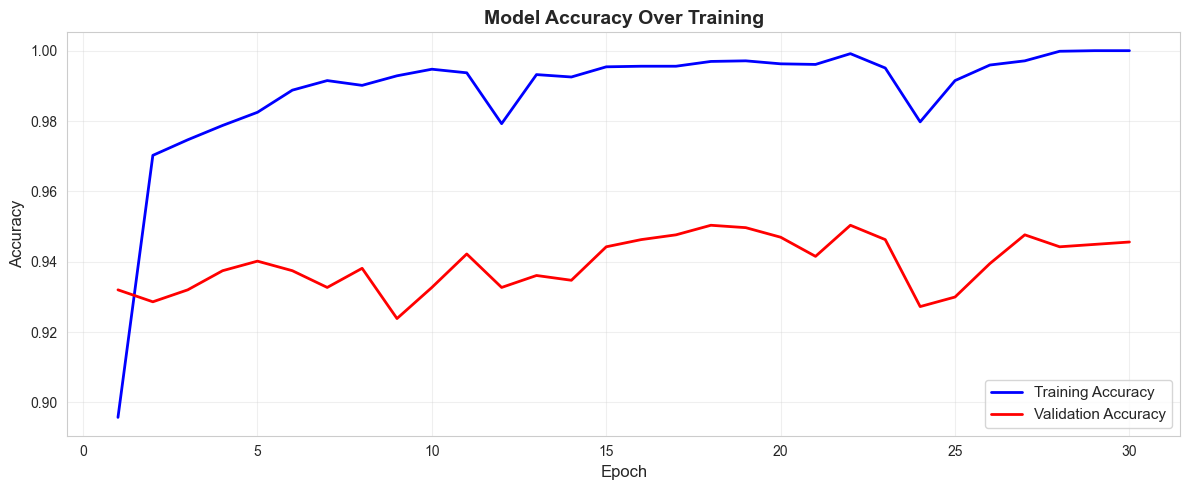

In [16]:
# TODO: Plot training accuracy vs validation accuracy over epochs
# Use best_history.history['accuracy'] and best_history.history['val_accuracy']
epochs = range(1, len(best_history.history['accuracy']) + 1)
if best_history is not None:
    plt.figure(figsize=(12, 5))
    plt.plot(epochs, best_history.history['accuracy'], 'b-', linewidth=2, label='Training Accuracy')
    plt.plot(epochs, best_history.history['val_accuracy'], 'r-', linewidth=2, label='Validation Accuracy')
    plt.title('Model Accuracy Over Training', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    plt.show()
else:
    print("Train best model first to visualize results")

### Visualize Training Progress - Loss

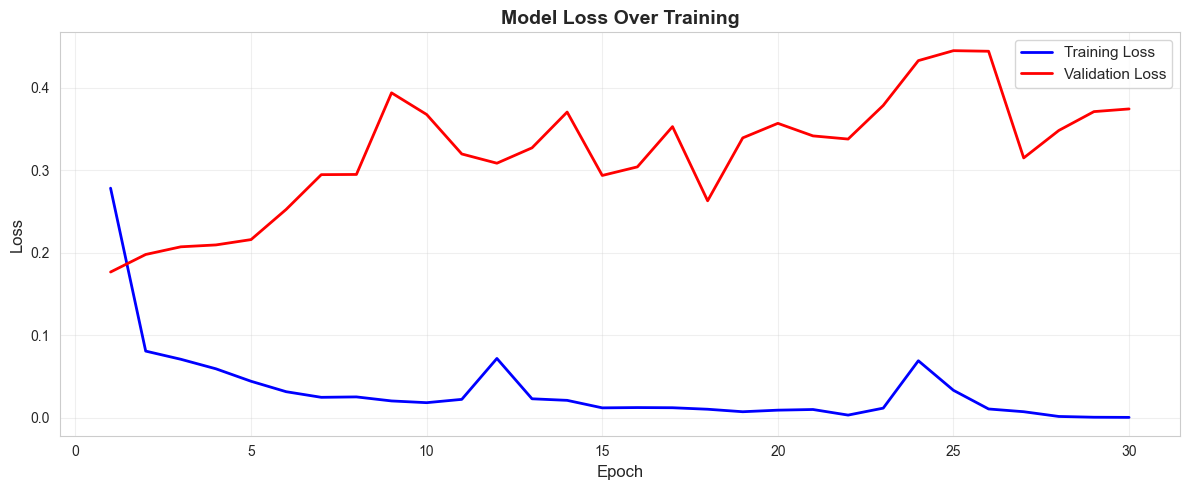

In [17]:
# TODO: Plot training loss vs validation loss over epochs
# Use best_history.history['loss'] and best_history.history['val_loss']

if best_history is not None:
    plt.figure(figsize=(12, 5))
    
    plt.plot(epochs, best_history.history['loss'], 'b-', linewidth=2, label='Training Loss')
    plt.plot(epochs, best_history.history['val_loss'], 'r-', linewidth=2, label='Validation Loss')
    plt.title('Model Loss Over Training', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(loc='upper right', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    plt.show()
else:
    print("Train best model first to visualize results")

---
## Step 6: Compare Against Unit 7 PCA + Random Forest

In [19]:
# TODO: Enter your Unit 7 PCA+Random Forest results here
# You should have recorded these in Unit 7
unit7_pca_rf_accuracy = 0.844588  # Replace with your Unit 7 test accuracy
unit7_pca_rf_time = 2.671865  # Replace with your Unit 7 training time (if you have it)

# Create comparison table
comparison = pd.DataFrame({
    'Model': [
        'Baseline NN (1 layer, 64 nodes)',
        'Best NN (Your Architecture)',
        'Unit 7: PCA + Random Forest'
    ],
    'Features/Layers': [
        '1 hidden layer',
        'Deep layer',
        '30 PCA components'
    ],
    'Test Accuracy': [
        baseline_test_accuracy,
        best_test_accuracy,
        unit7_pca_rf_accuracy
    ],
    'Training Time': [
        f"{baseline_time:.2f}s" if baseline_time else 'N/A',
        f"{best_time:.2f}s" if best_time else 'N/A',
        f"{unit7_pca_rf_time:.2f}s" if unit7_pca_rf_time else 'N/A'
    ]
})

print("\n" + "="*80)
print("MODEL COMPARISON: NEURAL NETWORKS VS UNIT 7")
print("="*80)
print(comparison.to_string(index=False))
print("="*80)


MODEL COMPARISON: NEURAL NETWORKS VS UNIT 7
                          Model   Features/Layers  Test Accuracy Training Time
Baseline NN (1 layer, 64 nodes)    1 hidden layer       0.921955         4.90s
    Best NN (Your Architecture)        Deep layer       0.925687         8.14s
    Unit 7: PCA + Random Forest 30 PCA components       0.844588         2.67s


### Reflection on Neural Network vs PCA+Random Forest
In the Markdown cell, write 2-3 sentences that answer the following questions:
- How does your best neural network compare to PCA+Random Forest?
- Did the neural network's ability to learn its own features from raw sensor data lead to better performance than manually engineering features with PCA? (2-3 sentences)

My best Neural Network was certainly better than my PCA+Reandom Forest model by almost 10%. NN's best accuracy was 92.5% vs PCA's accuarcy of 84.4%. In this case, yes, the neural network's ability to learn its own features from raw sensor data lead to better performance than maunal from PCA. This honeslty makes sense as caputring a pattern ususally leads to better results as the pattern has been identified vs. manual engineering as errors can happen or wrong manipulation of featurs can lead to worsen results.

---
## Step 7: Reflect on When to Use Neural Networks

### When to Use Neural Networks vs Simpler Models

In the Markdown cell below, write 3-4 sentences addressing the following: 
- Based on your results and what you learned in the resources, when should you use neural networks versus simpler models like random forests? Consider factors like data type (sensor data, images, text vs tabular business data), dataset size, interpretability needs, and performance requirements. 
- Give at least one example of when you'd choose neural networks and one example of when you'd choose random forests

 From these past two assingments, neural networks definitely is better for more complex/lots of features datasets like image pixels for example vs PCA would be better for smaller datasets with easier readability like a company's spreadsheet for revenue forecasts as it allows for easier predictability. NN justify their added complexity and training time by generally producing better results for the data types I mentioned. Coincrete examples taht I would give for each are for NN, trying to analyze if something is a human through a series of pictures where the model can train what a human expects to be like and then can tell from similar images once trained while with PCA, projecting a company's revenue through each quarter would be a great use for it as the dataset would be realitively small enough to manually reduce features that would simplify the data to be used in its predictive model.

---
## Step 8: Submit Your Work

Before submitting:
1. Make sure all code cells run without errors
2. Verify you have:
   - Baseline neural network trained and evaluated
   - At least 3 depth experiments (1, 2, 3 layers)
   - At least 3 width experiments (32, 64, 128 nodes)
   - Best model trained for 30 epochs with accuracy and loss plots
   - Comparison table with baseline NN, best NN, and Unit 7 PCA+RF
   - All reflection questions answered (2-3 or 3-4 sentences each)
3. Check that all visualizations display correctly

Then push to GitHub:
```bash
git add .
git commit -m 'completed neural networks assignment'
git push
```

Submit your GitHub repository link on the course platform.